# Myllia - echoes of silenced genes
---

**authors**: [fsb2210](https://www.kaggle.com/fsb2210), [julianc93](https://www.kaggle.com/julianc93)

The task is to train a model that is able to predict *expression changes in scRNA-seq data induced by CRISPRi perturbations*. For that, we have a dataset of 80 different perturbations and the *average expression values* of genes, plus an unperturbed case (*non-targeting sgRNA*).

## Introduction

This problem esentially consists of inputs of strings given by the `pert_symbol` column and an output vector space of dimension equal to the number of columns minus the one corresponding to the `pert_symbol` (i.e., a 5127-dimensional space).

Clearly, this dataset needs to be preprocessed. In particular, our preprocessing setup will be as follows:

- treat each of the genes (perturbation and output ones) as nodes of a large network. Bonds between nodes will represent (undirected) protein-protein interactions (PPIs) and (directed) transcription factor (TF) - target interactions,
- compute delta averages for each of the output vectors ($\Delta_{\rm avg}$),
- train a machine learning (ML) model using the preprocessed datasets created during steps 1 and 2,
- predict $\Delta_{\rm avg}$ on new genes using the validation set (`pert_ids_val.csv`).

> **NOTE**
> 
> Dependencies list is: matplotlib numpy pandas tqdm scipy scikit-learn seaborn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import kstest
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, MultiTaskLasso
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.multioutput import MultiOutputRegressor

In [2]:
import sys
sys.path.append("../src")

from metric import _score_impl, _weighted_cosine

def compute_metric_by_components(y_true, y_pred, w, baseline_wmae, eps=1e-12, max_log2=5.0, cos_left=0.0, cos_right=0.2):
    # - compute sum_wmae component
    abs_err = np.abs(y_true - y_pred)
    pred_wmae = np.mean(abs_err * w, axis=1)
    pred_wmae = np.maximum(pred_wmae, eps)
    baseline = np.maximum(baseline_wmae, eps)
    terms = np.log2(baseline / pred_wmae)
    terms = np.minimum(terms, max_log2)
    sum_wmae = float(np.sum(terms))

    # - compute wcos component using the existing function
    wcos = _weighted_cosine(y_pred.ravel(), y_true.ravel(), left=cos_left, right=cos_right, eps=eps)

    # - final score
    final_score = float(sum_wmae * max(0.0, wcos))

    return round(final_score, 5), round(sum_wmae, 4), round(wcos, 4)

Define global options:

In [14]:
experiment_name = "test"

# directory with data files
data_dir = "../data"
working_dir = "../data"

# random state integer value for reproducibility concerns
random_state = 42

# variance percentile to keep genes that vary significantly across perturbations, used for training a ML model
reduce_input_dim_by_variance = False
variance_percentile = 80  # keep top 20%

# reduce dimensions of output space genes to this number in the latent space
reduce_output_dim = True
n_latent = 75

# value for K-fold cross-validation technique
n_splits = 5

# filename of figure
fig_fname = f"{experiment_name}.png"

# OOF predictions and submission filenames (DataFrame structures saved)
oof_preds_fname = f"{experiment_name}.csv"
submission_fname = f"submissions_{experiment_name}.csv"

## Data loading

In [9]:
# train & validation sets
X = np.load(f"{data_dir}/processed/X_train.npy")
X_val = np.load(f"{data_dir}/processed/X_val.npy")
delta_train = np.load(f"{data_dir}/processed/Y_train.npy")

Load the ground truth values matching the training set. These values will be used during model training, in order to find the best solution (maximizing the metric):

In [10]:
# train & validation sets
train_df = pd.read_csv(f"{data_dir}/training_data_means.csv")
val_df = pd.read_csv(f"{data_dir}/pert_ids_val.csv")

# list of genes
train_pert_genes = train_df["pert_symbol"].tolist()[:-1]
val_pert_genes = val_df["pert"].tolist()
output_genes = train_df.columns[1:]

# ground truth
ground_truth = pd.read_csv(f"{data_dir}/training_data_ground_truth_table.csv")
weight_cols = [f"w_{g}" for g in output_genes]

# true values (used later on, when computing metric)
delta_true = ground_truth[output_genes].values
weights_true = ground_truth[weight_cols].values
baseline_true = ground_truth["baseline_wmae"].values

In [11]:
if reduce_input_dim_by_variance:
    gene_var = np.var(X, axis=0)
    var_threshold = np.percentile(gene_var, variance_percentile)
    selected_mask = gene_var >= var_threshold
    top_ind = np.where(selected_mask)[0]
    X = X[:, top_ind]
    X_val = X_val[:, top_ind]

# apply PCA to output vector to reduce dims into a latent space
n_internal = 80
n_external = X.shape[0] - n_internal
if reduce_output_dim:
    delta_internal = delta_train[:n_internal]
    pca_resp = PCA(n_components=n_latent, random_state=random_state)
    pca_resp.fit(delta_internal)
    delta_pca = pca_resp.transform(delta_train)

In [12]:
X.shape, X_val.shape, delta_train.shape, delta_pca.shape

((4473, 6154), (60, 6154), (4473, 5127), (4473, 75))

## Model training

We are now ready to train a machine learning model using the results of the diffusion of perturbations in the graph as inputs and the computed delta expressions for 5127 genes as outputs.

In order to accomplish this task, we use a nested cross-validation (CV) technique containing two loops:

1. an inner CV that is used to tune the best hyperparameters of the model. takes samples of 79 perturbations, splits it into different folds to test different parameters and chooses the best ones,
2. an outer loop (**leave-one-out**, LOO) that is used to evaluate the best trained models (from the inner loop) and it generates a prediction for *every sample* in the set without that sample ever being used to train the final model that predicted it.

This is required for small datasets to avoid data leakages that would give rise to a very biased score.

Thus, the workflow for a single step is:

1. *split*: take sample 1 out (`va`), keep samples 2-80 (`tr`),
2. *scale*: fit scaler on samples 2-80, then transform samples 2-80 and sample 1,
3. *inner CV (tuning)*:
   - `RidgeCV` takes samples 2-80,
   - splits samples 2-80 into 3 chunks,
   - tests different alphas to see which one works best on the chunks,
   - picks  best parameters (e.g., `alpha` = 0.5)
4. *final train*: `RidgeCV` retrains on all of samples 2-80 using `alpha` = 0.5,
5. *out-of-fold (OOF) predict*: `RidgeCV` from step before makes a prediction on sample 1.

In [15]:
start_time = time.time()

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

oof_preds = np.zeros_like(delta_train)
oof_counts = np.zeros(len(delta_train))
val_preds = np.zeros((len(X_val), len(output_genes)))
scores, wmae, wcos = [], [], []
scaling_factors = []
pbar = tqdm(enumerate(cv.split(X)), desc="model training", total=n_splits, initial=0)
for k, (tr, va) in pbar:
    X_tr, X_va = X[tr], X[va]
    Y_tr, Y_va = delta_pca[tr], delta_train[va]

    # === Lasso model
    # multi_model = MultiTaskLasso(alpha=1e-3, random_state=random_state)
    # === Ridge model
    multi_model = MultiOutputRegressor(Ridge(alpha=20))
    multi_model.fit(X_tr, Y_tr)

    # predictions
    Y_pred = pca_resp.inverse_transform(multi_model.predict(X_va))
    Y_val = pca_resp.inverse_transform(multi_model.predict(X_val))

    std_pred = np.std(Y_pred)
    std_true = np.std(Y_va)
    factor = std_true / std_pred if std_pred > 0 else 1
    scaling_factors.append(factor)

    # save OOF predictions
    oof_preds[va] += Y_pred * factor
    oof_counts[va] += 1
    # make predictions on validation set, final answer is average over the entire models
    val_preds += Y_val / n_splits

    internal_mask = va < n_internal
    if np.any(internal_mask):
        # filter the predictions and true values to ONLY the internal samples
        Y_pred_internal = Y_pred[internal_mask]
        Y_va_internal = Y_va[internal_mask]

        # get weights and baselines
        internal_indices = va[internal_mask]
        W_va = weights_true[internal_indices]
        B_va = baseline_true[internal_indices]

        # compute metric
        fold_score, fold_wmae, fold_wcos = compute_metric_by_components(Y_va_internal, Y_pred_internal, W_va, B_va)
        scores.append(fold_score)
        wmae.append(fold_wmae)
        wcos.append(fold_wcos)

        pbar.set_postfix({"score": f"{fold_score:.4f}", "wmae": f"{fold_wmae:.4f}", "wcos": f"{fold_wcos:.4f}"})
    else:
        pass

training_time = time.time() - start_time
print(f"training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

model training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [09:16<00:00, 111.27s/it, score=-0.1039, wmae=-0.2563, wcos=0.4052]

training completed in 556.56 seconds (9.28 minutes)


In [16]:
# average OOF predictions (each sample seen multiple times)
## oof_preds_train = oof_preds # / oof_counts[:, np.newaxis]
oof_predictions = oof_preds[:n_internal]
overall_score, overall_wmae, overall_wcos = compute_metric_by_components(delta_train[:n_internal], oof_predictions, weights_true, baseline_true)

median_scale = np.median(scaling_factors)
val_preds *= median_scale

In [30]:
print(f"- Per-fold averages:")
print(f"  - score:    {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
print(f"  - sum_wmae: {np.mean(wmae):.4f} +/- {np.std(wmae):.4f}")
print(f"  - wcos:     {np.mean(wcos):.4f} +/- {np.std(wcos):.4f}")

print(f"- Overall OOF (all 80 samples):")
print(f"  - score:    {overall_score:.4f}")
print(f"  - sum_wmae: {overall_wmae:.4f}")
print(f"  - wcos:     {overall_wcos:.4f}")

pred_std_per_sample = oof_predictions.std(axis=1)
true_std_per_sample = delta_train.std(axis=1)
print(f"- Diagnostics:")
print(f"  - pred_std/true_std ratio: {pred_std_per_sample.mean() / true_std_per_sample.mean():.3f}")

abs_err = np.abs(delta_train[:n_internal] - oof_predictions)
pred_wmae_per_pert = np.mean(abs_err * weights_true, axis=1)
n_beating = (pred_wmae_per_pert < baseline_true).sum()
print(f"  - perturbations beating baseline: {n_beating}/80")

- Per-fold averages:
  - score:    -0.1245 +/- 0.0254
  - sum_wmae: -0.5020 +/- 0.2247
  - wcos:     0.2834 +/- 0.0827
- Overall OOF (all 80 samples):
  - score:    0.3488
  - sum_wmae: 1.4697
  - wcos:     0.2373
- Diagnostics:
  - pred_std/true_std ratio: 0.783
  - perturbations beating baseline: 53/80


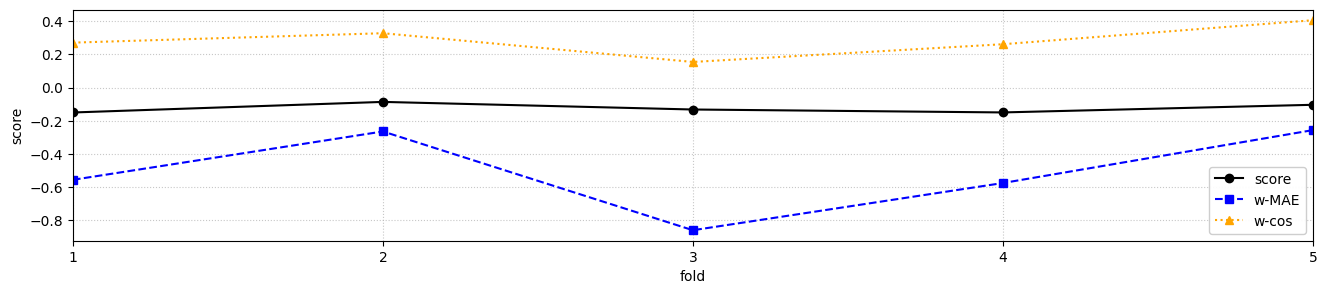

In [18]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.set_xlabel("fold")
ax.set_ylabel("score")
ax.set_xlim(1, len(scores))
ax.set_xticks(range(1, len(scores)+1))
ax.grid(True, linestyle=":", alpha=0.7)
xx = range(1, len(scores)+1)
ax.plot(xx, scores, marker="o", label="score", color="black", linewidth=1.5)
ax.plot(xx, wmae, marker="s", label="w-MAE", color="blue", linewidth=1.5, linestyle="--")
ax.plot(xx, wcos, marker="^", label="w-cos", color="orange", linewidth=1.5, linestyle=":")
ax.legend(loc="best", frameon=True, framealpha=0.95);

In [19]:
# calculate correlation per gene (axis=0)
corrs = []
for i in range(delta_true.shape[1]):
    # handle cases where variance is 0 to avoid NaNs
    if np.std(delta_true[:, i]) > 1e-6:
        corr = np.corrcoef(delta_true[:, i], oof_predictions[:, i])[0, 1]
        corrs.append(corr)
corrs = np.array(corrs)

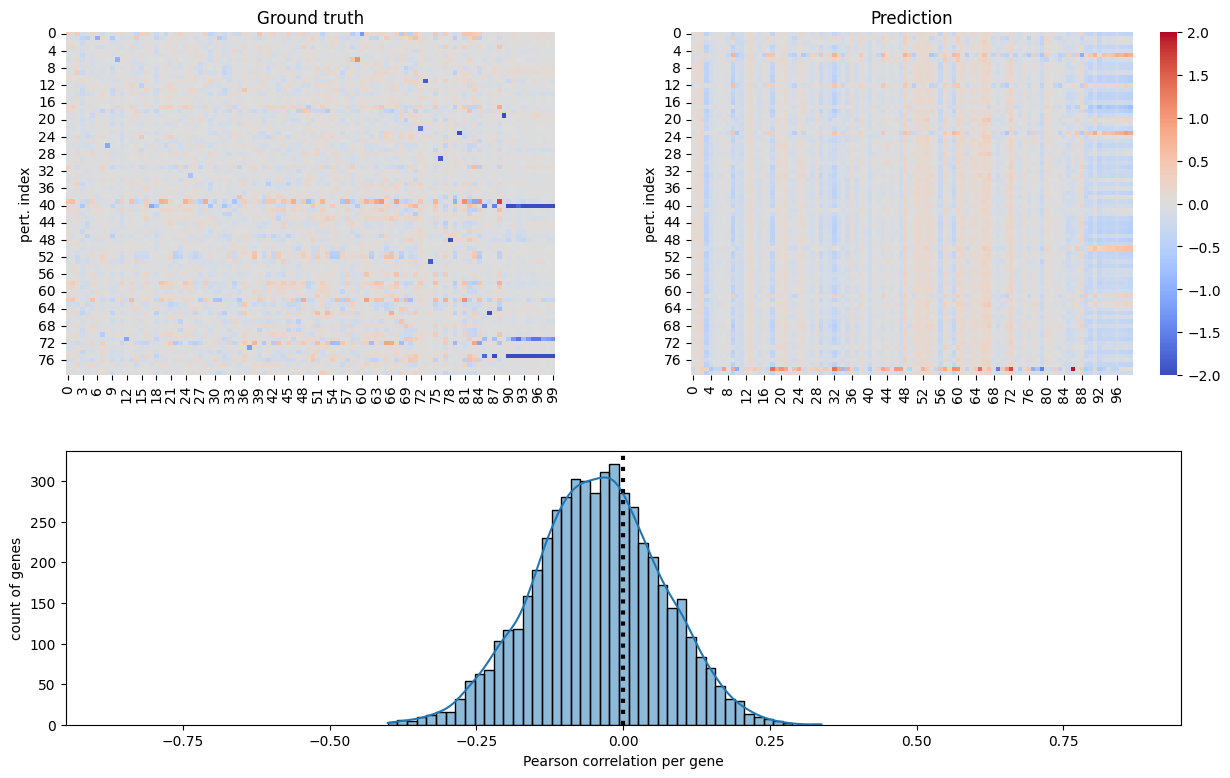

In [20]:
# select top 50 most variable genes based on ground truth variance
gene_vars = np.var(delta_train[:n_internal,:], axis=0)
top_idx = np.argsort(gene_vars)[-100:]
y_true_subset = delta_train[:n_internal, top_idx]
pred_subset = oof_predictions[:, top_idx]

fig_shape = (16, 9)
fig = plt.figure(figsize=fig_shape)

# Top row: two heatmaps with shared colorbar
ax1 = plt.subplot2grid((20, 20), (0, 0), colspan=8, rowspan=10)
im1 = sns.heatmap(y_true_subset, cmap="coolwarm", center=0, ax=ax1, cbar=False, vmin=-2, vmax=2)
ax1.set_title("Ground truth")
ax1.set_ylabel("pert. index")

ax2 = plt.subplot2grid((20, 20), (0, 10), colspan=9, rowspan=10)
im2 = sns.heatmap(pred_subset, cmap="coolwarm", center=0, ax=ax2, cbar=True, vmin=-2, vmax=2)
ax2.set_title("Prediction")
ax2.set_ylabel("pert. index")

# Bottom row: correlation histogram spanning full width
ax3 = plt.subplot2grid((20, 20), (12, 0), colspan=18, rowspan=9)
sns.histplot(corrs, kde=True, ax=ax3)
ax3.axvline(x=0, color="black", linestyle=":", lw=3)
ax3.set_xlim(-0.95, 0.95)
ax3.set_xlabel("Pearson correlation per gene")
ax3.set_ylabel("count of genes")

plt.savefig(fig_fname);

In [24]:
pvalues = []
for k in range(delta_train.shape[0]):
    pvalues.append(kstest(delta_train[k, :], oof_preds[k, :]).pvalue)

In [25]:
print(f"mean p-value (along perturbations): {np.mean(pvalues):.2e} +/- {np.std(pvalues):.2e}")

mean p-value (along perturbations): 1.23e-08 +/- 6.21e-07


In [26]:
oof_predictions.min(), oof_predictions.max(), delta_train.min(), delta_train.max()

(np.float64(-1.5183052977188485),
 np.float64(1.9394310487253925),
 np.float64(-5.29206177),
 np.float64(4.16471664))

In addition, we also save OOF predictions in case we want to use them for an ensemble stacking or hill climbing approach:

In [27]:
oof_preds_df = pd.DataFrame(oof_predictions, columns=output_genes)
oof_preds_df.insert(0, "pert_symbol", train_pert_genes)
oof_preds_df.to_csv(oof_preds_fname, index=False)
oof_preds_df.head()

,pert_symbol,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,ACLY,0.048659,0.000539,-0.006765,0.000389,-0.032832,0.000288,-0.006102,-0.002652,0.018766,...,0.124213,-0.000398,0.007619,0.003839,0.024405,0.037265,-0.054264,-0.036789,-0.047998,-0.026145
1,ALDOA,0.014574,-0.018780,-0.032069,-0.047582,0.076318,-0.006174,-0.098750,-0.026201,-0.000003,...,0.049382,-0.000587,0.045386,-0.002559,0.027016,0.039149,-0.045445,-0.114601,0.146369,-0.117321
2,APAF1,0.040701,-0.016986,-0.026733,-0.018358,0.001831,-0.002469,-0.050278,-0.005970,0.012082,...,0.075780,0.000600,-0.001695,0.003415,0.029543,0.018817,-0.055300,-0.083938,0.077037,-0.071772
3,ARID2,0.036809,0.000627,-0.008475,0.001911,-0.031194,0.001207,0.001338,-0.000603,0.019270,...,0.105280,-0.000347,0.000870,0.007001,0.028223,0.031148,-0.022900,-0.038848,-0.045407,-0.023701
4,BAG1,0.025290,-0.005334,-0.009793,0.005325,-0.033012,0.000675,-0.016633,-0.002118,0.019326,...,0.108950,-0.000326,0.022944,0.006488,0.028830,0.025975,-0.044772,-0.040373,-0.016420,-0.031061


In [28]:
train_df.head()

,pert_symbol,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,ACLY,0.311642,0.022102,0.100949,0.378671,0.715857,0.000000,0.118900,0.030792,0.087006,...,0.290693,0.002349,0.638608,0.031022,0.036856,0.097390,0.914845,0.647727,0.720461,0.603572
1,ALDOA,0.627445,0.043961,0.094335,0.442062,0.658125,0.000000,0.200191,0.000000,0.061549,...,0.390909,0.000000,0.371624,0.045867,0.087408,0.124600,0.821529,0.801302,0.545344,0.553567
2,APAF1,0.467114,0.030714,0.090910,0.470155,0.732770,0.002820,0.118370,0.025851,0.137382,...,0.359183,0.000000,0.535496,0.009991,0.053445,0.069219,0.855117,0.709241,0.674747,0.667791
3,ARID2,0.517185,0.018776,0.102561,0.445692,0.687079,0.010236,0.124519,0.016378,0.123456,...,0.353383,0.000000,0.557026,0.017552,0.062452,0.094811,0.731613,0.614643,0.629297,0.619404
4,BAG1,0.409021,0.034862,0.129969,0.462849,0.819877,0.002999,0.125579,0.002677,0.131047,...,0.286078,0.000000,0.611761,0.008581,0.052864,0.126885,0.899319,0.714828,0.646969,0.636020


## Inference

We are now ready to save predictions on the 60 genes found in the validation dataset along with 60 more dummy predictions for the not-yet available genes in the test dataset:

In [309]:
val_ids = val_df["pert_id"].tolist()

preds = pd.DataFrame(val_preds, columns=output_genes)
preds.insert(0, "pert_id", val_ids)
pad = pd.DataFrame(0, index=range(60), columns=output_genes)
pad.insert(0, "pert_id", [f"pert_{i}" for i in range(61, 121)])

submission = pd.concat([preds, pad], ignore_index=True)
submission.to_csv(submission_fname, index=False)
submission.head()

,pert_id,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,pert_1,0.033634,0.001880,-0.005362,-0.007310,-0.043626,-0.000292,-0.000787,-0.002314,0.035401,...,0.077303,-0.000452,0.019877,0.005603,0.019877,0.039562,-0.036223,-0.093037,-0.049574,0.015363
1,pert_2,0.034482,0.003919,-0.002942,-0.005378,-0.032331,-0.000408,-0.015096,-0.003394,0.030315,...,0.098726,0.000425,0.002371,0.004626,0.017360,0.035585,-0.050260,-0.067021,-0.067253,-0.017492
2,pert_3,0.057438,0.009075,-0.001377,0.008509,-0.067581,0.000863,0.038459,0.012048,0.036388,...,0.083012,-0.000998,0.002070,0.012341,0.028168,0.044950,-0.047642,-0.090914,-0.072060,0.022639
3,pert_4,0.028387,-0.022366,-0.030511,-0.056077,0.002867,-0.000343,-0.062112,-0.003111,0.039721,...,0.040245,-0.001409,-0.007914,0.005912,0.027449,0.025895,-0.034399,-0.093605,0.049561,-0.065022
4,pert_5,0.053719,0.004344,-0.002324,0.002762,-0.057394,0.001638,0.027153,0.011470,0.040480,...,0.103340,0.000156,-0.004423,0.007490,0.018075,0.036809,-0.064328,-0.102087,-0.094792,0.020122


---

In [21]:
# !rm -f info.txt links.txt